# Day 5 — Baseline Models
**Real Estate Fraud Detection**

Goal: Train 3 baseline models with default params, log to MLflow, document results.

| Tier | Model | Why |
|------|-------|-----|
| 1 | Logistic Regression (L2) | Linear baseline — improvement benchmark |
| 2 | LightGBM (tabular) | Main model — tree-based, handles imbalance |
| 3 | LightGBM (tabular+text) | Multi-modal — text disabled for this dataset |

**Prerequisites:** Day 4 completed → `data/splits/` folder with 4 parquet files

## 0. Set Project Root

In [1]:
import os
from pathlib import Path

project_root = Path.cwd()
while not (project_root / 'configs').exists():
    project_root = project_root.parent
os.chdir(project_root)
print(f'Working directory: {os.getcwd()}')

Working directory: C:\Users\mehal\Downloads\machinelearning\real_estate_fraud_detection


## 1. Imports & Config

In [2]:
import os, sys
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
from pathlib import Path

from src.ingestion import load_config
from src.models import (
    setup_mlflow,
    train_logistic_regression,
    train_lgbm_tabular,
    train_lgbm_text,
    build_baseline_report,
    save_model,
)
from src.evaluate import (
    pr_auc_score,
    plot_all_pr_curves,
    plot_threshold_analysis,
)

CONFIG_PATH = 'configs/config.yaml'
PLOTS_DIR   = 'reports/plots'
cfg = load_config(CONFIG_PATH)

setup_mlflow(cfg)
Path(PLOTS_DIR).mkdir(parents=True, exist_ok=True)

print(f'Config: {cfg["project"]["name"]} v{cfg["project"]["version"]}')
print(f'MLflow experiment: {cfg["mlflow"]["experiment_name"]}')
print(f'CV folds: {cfg["model"]["cv_folds"]}')
print(f'Group col: {cfg["columns"]["group_col"]}')

2026-05-14 09:28:51,944 - src.ingestion - INFO - Config loaded from configs\config.yaml — project: real_estate_fraud_detection v1.1.0
C:\Users\mehal\AppData\Roaming\Python\Python312\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026-05-14 09:28:51,976 - src.models - INFO - MLflow: tracking_uri=logs/mlruns | experiment=real-estate-fraud-v1


Config: real_estate_fraud_detection v1.1.0
MLflow experiment: real-estate-fraud-v1
CV folds: 5
Group col: city


## 2. Load Splits

> Splits were frozen in Day 4. **Never reload from labeled.parquet and re-split** — that would change the test set.

In [3]:
splits_path = Path(cfg['data']['splits_path'])

X_train = pd.read_parquet(splits_path / 'X_train.parquet')
X_test  = pd.read_parquet(splits_path / 'X_test.parquet')
y_train = pd.read_parquet(splits_path / 'y_train.parquet').squeeze()
y_test  = pd.read_parquet(splits_path / 'y_test.parquet').squeeze()

print(f'X_train : {X_train.shape}  |  fraud: {y_train.mean()*100:.2f}%')
print(f'X_test  : {X_test.shape}   |  fraud: {y_test.mean()*100:.2f}%')
print(f'\nColumns: {list(X_train.columns)}')

X_train : (240000, 24)  |  fraud: 7.82%
X_test  : (60000, 24)   |  fraud: 7.82%

Columns: ['status', 'price', 'bed', 'bath', 'acre_lot', 'city', 'state', 'zip_code', 'house_size', 'prev_sold_date', 'price_log', 'house_size_log', 'acre_lot_log', 'price_per_sqft', 'bath_per_bed', 'is_large_property', 'days_since_last_sale', 'sold_year', 'sold_month', 'city_median_price', 'price_vs_city_median', 'state_median_price', 'zip_listing_count', 'city_fraud_rate']


## 3. Tier 1 — Logistic Regression Baseline

Linear baseline — sets the floor. LightGBM must beat this clearly.

In [4]:
print('Training Tier 1 — Logistic Regression...')
lr_results = train_logistic_regression(X_train, y_train, cfg)

print(f'\n✅ LR Results:')
print(f'  PR-AUC : {lr_results["mean_pr_auc"]:.4f} ± {lr_results["std_pr_auc"]:.4f}')
print(f'  Recall@95P : {lr_results["mean_recall"]:.4f}')
print(f'  OOF PR-AUC : {lr_results["oof_pr_auc"]:.4f}')
print(f'  MLflow run : {lr_results["run_id"]}')

2026-05-14 09:28:52,252 - src.models - INFO - Training Tier 1 — Logistic Regression (baseline)


Training Tier 1 — Logistic Regression...


2026-05-14 09:28:53,762 - src.features - INFO - FeatureEngineer.fit() — computing fold-dependent stats
2026-05-14 09:28:54,076 - src.features - INFO -   Cities: 1422 | States: 54 | Zip codes: 18425
2026-05-14 09:28:54,213 - src.features - INFO - Fold-dependent features added — 24 total cols
2026-05-14 09:28:54,256 - src.features - INFO - Fold-dependent features added — 24 total cols
2026-05-14 09:28:54,465 - src.features - INFO - Stateless features added — 9 new columns
2026-05-14 09:28:54,526 - src.features - INFO - Stateless features added — 9 new columns
2026-05-14 09:28:54,529 - src.preprocessing - INFO - Preprocessor built — 19 numerical, 2 categorical
C:\Users\mehal\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
2026-05-14 09:28:59,956 - src.models - INFO -   Fold 1/


✅ LR Results:
  PR-AUC : 0.6031 ± 0.0558
  Recall@95P : 0.0000
  OOF PR-AUC : 0.5952
  MLflow run : 8b6e3f4ca81f48a1921905a1515eb20a


## 4. Tier 2 — LightGBM Tabular Baseline

In [5]:
print('Training Tier 2 — LightGBM tabular...')
lgbm_results = train_lgbm_tabular(X_train, y_train, cfg)

print(f'\n✅ LightGBM Results:')
print(f'  PR-AUC : {lgbm_results["mean_pr_auc"]:.4f} ± {lgbm_results["std_pr_auc"]:.4f}')
print(f'  Recall@95P : {lgbm_results["mean_recall"]:.4f}')
print(f'  OOF PR-AUC : {lgbm_results["oof_pr_auc"]:.4f}')
print(f'  Improvement over LR: +{lgbm_results["mean_pr_auc"] - lr_results["mean_pr_auc"]:.4f}')

Training Tier 2 — LightGBM tabular...


2026-05-14 09:29:23,198 - src.models - INFO - Training Tier 2 — LightGBM tabular baseline
2026-05-14 09:29:23,200 - src.models - INFO -   scale_pos_weight: 11.78 (fraud_rate=0.078)
2026-05-14 09:29:23,615 - src.features - INFO - FeatureEngineer.fit() — computing fold-dependent stats
2026-05-14 09:29:23,919 - src.features - INFO -   Cities: 1422 | States: 54 | Zip codes: 18425
2026-05-14 09:29:24,048 - src.features - INFO - Fold-dependent features added — 24 total cols
2026-05-14 09:29:24,104 - src.features - INFO - Fold-dependent features added — 24 total cols
2026-05-14 09:29:24,287 - src.features - INFO - Stateless features added — 9 new columns
2026-05-14 09:29:24,351 - src.features - INFO - Stateless features added — 9 new columns
2026-05-14 09:29:24,355 - src.preprocessing - INFO - Preprocessor built — 19 numerical, 2 categorical
C:\Users\mehal\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGB


✅ LightGBM Results:
  PR-AUC : 0.7807 ± 0.0371
  Recall@95P : 0.0856
  OOF PR-AUC : 0.7701
  Improvement over LR: +0.1776


## 5. Tier 3 — LightGBM Tabular + Text

> Text disabled for this dataset — `text_features.enabled: false`. Text modality returns zero arrays. Architecture ready for when description column is available.

In [6]:
print('Training Tier 3 — LightGBM + text (text disabled = same as Tier 2)...')
lgbm_text_results = train_lgbm_text(X_train, y_train, cfg)

print(f'\n✅ LightGBM+Text Results:')
print(f'  PR-AUC : {lgbm_text_results["mean_pr_auc"]:.4f} ± {lgbm_text_results["std_pr_auc"]:.4f}')
print(f'  Recall@95P : {lgbm_text_results["mean_recall"]:.4f}')
print(f'  OOF PR-AUC : {lgbm_text_results["oof_pr_auc"]:.4f}')

2026-05-14 09:29:58,580 - src.models - INFO - Training Tier 3 — LightGBM tabular + text


Training Tier 3 — LightGBM + text (text disabled = same as Tier 2)...


2026-05-14 09:29:59,083 - src.features - INFO - FeatureEngineer.fit() — computing fold-dependent stats
2026-05-14 09:29:59,325 - src.features - INFO -   Cities: 1422 | States: 54 | Zip codes: 18425
2026-05-14 09:29:59,419 - src.features - INFO - Fold-dependent features added — 24 total cols
2026-05-14 09:29:59,451 - src.features - INFO - Fold-dependent features added — 24 total cols
2026-05-14 09:29:59,594 - src.features - INFO - Stateless features added — 9 new columns
2026-05-14 09:29:59,646 - src.features - INFO - Stateless features added — 9 new columns
2026-05-14 09:29:59,648 - src.preprocessing - INFO - Preprocessor built — 19 numerical, 2 categorical
C:\Users\mehal\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2026-05-14 09:30:06,155 - src.models - INFO -   Fold 1/5 — PR-AUC: 0.8006 | Recall@95P: 0.1024 | 7.1s
2026-05-14 09:30:06,


✅ LightGBM+Text Results:
  PR-AUC : 0.7807 ± 0.0371
  Recall@95P : 0.0856
  OOF PR-AUC : 0.7701


## 6. Baseline Report — All 3 Tiers

In [7]:
all_results = {
    'Logistic Regression':  lr_results,
    'LightGBM (tabular)':   lgbm_results,
    'LightGBM (tab+text)':  lgbm_text_results,
}

baseline_report = build_baseline_report(all_results)
print('=== BASELINE REPORT ===')
print(baseline_report.to_string(index=False))

# Save report
report_path = Path(cfg['paths']['reports']) / 'baseline_report.csv'
baseline_report.to_csv(report_path, index=False)
print(f'\n✅ Report saved → {report_path}')

=== BASELINE REPORT ===
              Model  PR-AUC Mean  PR-AUC Std  Recall@95P  OOF PR-AUC MLflow Run ID
 LightGBM (tabular)       0.7807      0.0371      0.0856      0.7701   d682b5b1...
LightGBM (tab+text)       0.7807      0.0371      0.0856      0.7701   fe0a8f36...
Logistic Regression       0.6031      0.0558      0.0000      0.5952   8b6e3f4c...

✅ Report saved → reports\baseline_report.csv


## 7. PR Curves — All Models

2026-05-14 09:30:35,948 - src.evaluate - INFO - PR curves saved → reports/plots/pr_curves_comparison.png


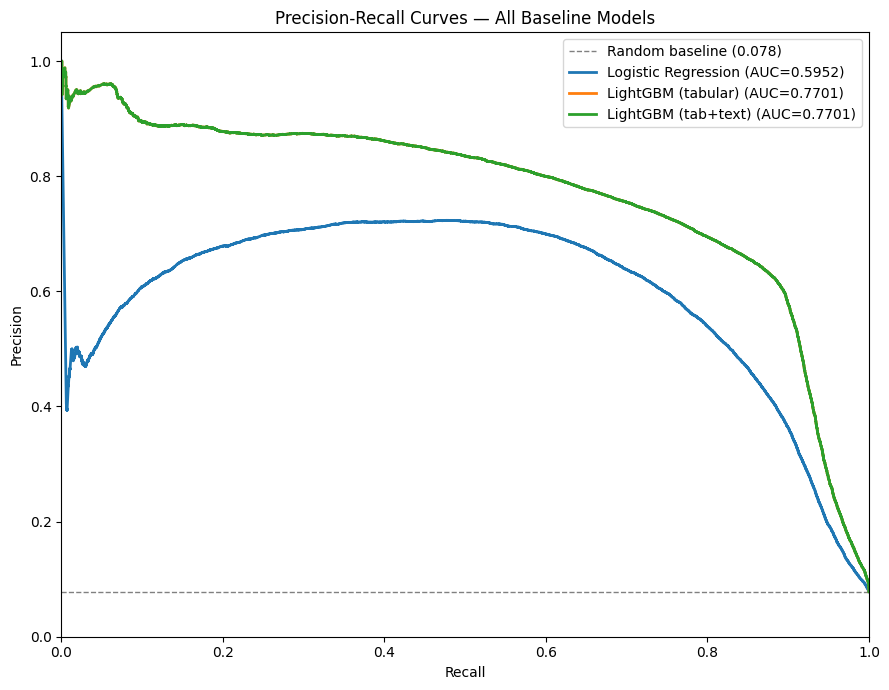

In [8]:
plot_all_pr_curves(
    results={
        'Logistic Regression': lr_results['oof_probs'],
        'LightGBM (tabular)':  lgbm_results['oof_probs'],
        'LightGBM (tab+text)': lgbm_text_results['oof_probs'],
    },
    y_true=y_train.values,
    plots_dir=PLOTS_DIR,
    show=True,
)

## 8. Per-Fold Variance Check

High fold variance = model unstable = need more regularization or data.

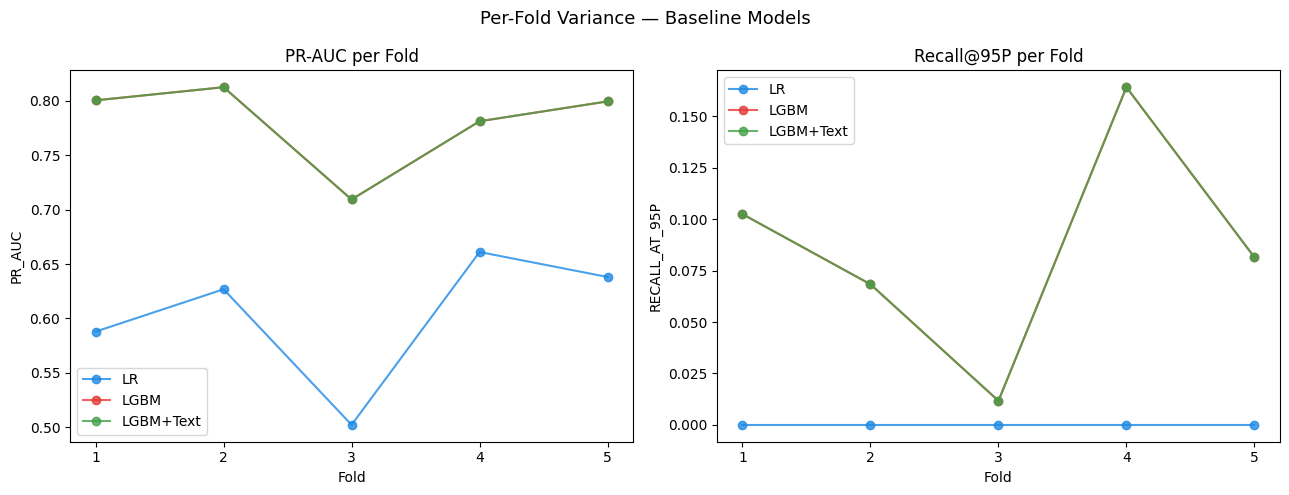

Fold variance summary:
  LR: std=0.0558 ⚠️  HIGH — check regularization
  LGBM: std=0.0371 ✅
  LGBM+Text: std=0.0371 ✅


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

model_names = ['LR', 'LGBM', 'LGBM+Text']
model_res   = [lr_results, lgbm_results, lgbm_text_results]
colors      = ['#1E88E5', '#E53935', '#43A047']

for ax_idx, metric_key, title in [
    (0, 'pr_auc',        'PR-AUC per Fold'),
    (1, 'recall_at_95p', 'Recall@95P per Fold'),
]:
    for name, res, color in zip(model_names, model_res, colors):
        vals = [f[metric_key] for f in res['fold_metrics']]
        axes[ax_idx].plot(range(1, len(vals)+1), vals, 'o-',
                          label=name, color=color, alpha=0.8)
    axes[ax_idx].set_xlabel('Fold')
    axes[ax_idx].set_ylabel(metric_key.upper())
    axes[ax_idx].set_title(title)
    axes[ax_idx].legend()
    axes[ax_idx].set_xticks(range(1, cfg['model']['cv_folds']+1))

plt.suptitle('Per-Fold Variance — Baseline Models', fontsize=13)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/fold_variance.png', dpi=150)
plt.show()

# Flag high variance
print('Fold variance summary:')
for name, res in zip(model_names, model_res):
    std = res['std_pr_auc']
    flag = ' ⚠️  HIGH — check regularization' if std > 0.05 else ' ✅'
    print(f'  {name}: std={std:.4f}{flag}')

## 9. Threshold Analysis — Best Model

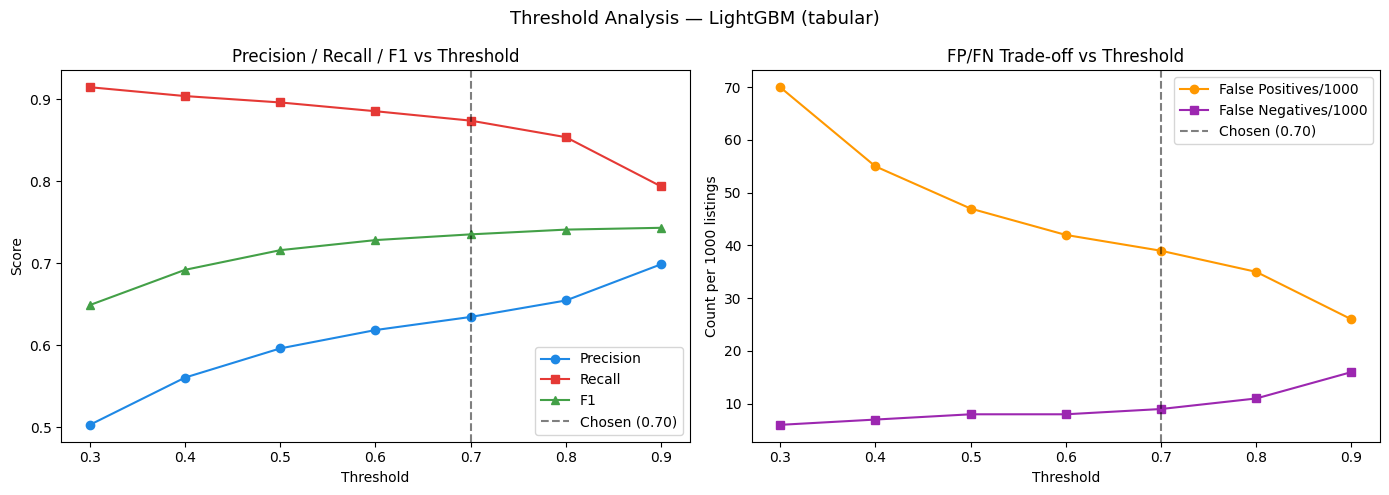


Threshold sensitivity — LightGBM (tabular):
 Threshold  Precision  Recall     F1  FP/1000  FN/1000
       0.3     0.5027  0.9148 0.6489       70        6
       0.4     0.5604  0.9040 0.6919       55        7
       0.5     0.5960  0.8962 0.7159       47        8
       0.6     0.6184  0.8855 0.7282       42        8
       0.7     0.6344  0.8740 0.7352       39        9
       0.8     0.6545  0.8538 0.7410       35       11
       0.9     0.6987  0.7937 0.7432       26       16


In [10]:
# Use best model OOF probs for threshold analysis
best_name = baseline_report.iloc[0]['Model']
best_probs = {
    'Logistic Regression': lr_results['oof_probs'],
    'LightGBM (tabular)':  lgbm_results['oof_probs'],
    'LightGBM (tab+text)': lgbm_text_results['oof_probs'],
}[best_name]

threshold_df = plot_threshold_analysis(
    y_train.values, best_probs, best_name,
    plots_dir=PLOTS_DIR, show=True
)
print(f'\nThreshold sensitivity — {best_name}:')
print(threshold_df.to_string(index=False))

## 10. Save OOF Predictions

In [11]:
oof_df = pd.DataFrame({
    'y_true':           y_train.values,
    'oof_lr':           lr_results['oof_probs'],
    'oof_lgbm':         lgbm_results['oof_probs'],
    'oof_lgbm_text':    lgbm_text_results['oof_probs'],
})

oof_path = Path(cfg['data']['processed_path']) / 'oof_predictions.parquet'
oof_df.to_parquet(oof_path, index=False)
print(f'✅ OOF predictions saved → {oof_path}')
print(f'   Shape: {oof_df.shape}')
print(f'   Columns: {list(oof_df.columns)}')

✅ OOF predictions saved → data\processed\oof_predictions.parquet
   Shape: (240000, 4)
   Columns: ['y_true', 'oof_lr', 'oof_lgbm', 'oof_lgbm_text']


## 11. MLflow Run Summary

In [12]:
print('=== MLflow Runs ===')
for name, res in zip(
    ['baseline_lr', 'baseline_lgbm', 'baseline_lgbm_text'],
    [lr_results, lgbm_results, lgbm_text_results]
):
    print(f'  {name:<25} run_id={res["run_id"]}')

print(f'\nMLflow UI: mlflow ui --backend-store-uri {cfg["mlflow"]["tracking_uri"]}')
print(f'Then open: http://127.0.0.1:5000')

=== MLflow Runs ===
  baseline_lr               run_id=8b6e3f4ca81f48a1921905a1515eb20a
  baseline_lgbm             run_id=d682b5b1f82b4bc79727bafa3d7f7bfa
  baseline_lgbm_text        run_id=fe0a8f364198480d971356abc24e5aab

MLflow UI: mlflow ui --backend-store-uri logs/mlruns
Then open: http://127.0.0.1:5000


## 12. Day 5 Exit Criteria

In [13]:
print('=== DAY 5 EXIT CRITERIA ===')

checks = [
    ('Tier 1 LR trained',           lr_results['mean_pr_auc'] > 0),
    ('Tier 2 LGBM trained',         lgbm_results['mean_pr_auc'] > 0),
    ('Tier 3 LGBM+text trained',    lgbm_text_results['mean_pr_auc'] > 0),
    ('LGBM beats LR',               lgbm_results['mean_pr_auc'] > lr_results['mean_pr_auc']),
    ('3 MLflow runs logged',        all(r['run_id'] for r in [lr_results, lgbm_results, lgbm_text_results])),
    ('OOF predictions saved',       oof_path.exists()),
    ('Baseline report saved',       report_path.exists()),
    ('Low fold variance LGBM',      lgbm_results['std_pr_auc'] < 0.05),
]

all_pass = True
for label, result in checks:
    icon = '☑' if result else '☒'
    if not result:
        all_pass = False
    print(f'  {icon} {label}')

print(f'\n{"✅ All checks passed" if all_pass else "⚠️  Some checks failed — review above"}')
print(f'\n=== BASELINE NUMBERS TO FILL IN ===')
print(f'| Model                | PR-AUC Mean | PR-AUC Std | Recall@95P |')
print(f'|----------------------|-------------|------------|------------|')
for name, res in zip(['Logistic Regression', 'LightGBM (tabular)', 'LightGBM (tab+text)'],
                     [lr_results, lgbm_results, lgbm_text_results]):
    print(f'| {name:<20} | {res["mean_pr_auc"]:>11.4f} | {res["std_pr_auc"]:>10.4f} | {res["mean_recall"]:>10.4f} |')

print(f'\n→ Ready for Day 6 — Optuna Hyperparameter Tuning')

=== DAY 5 EXIT CRITERIA ===
  ☑ Tier 1 LR trained
  ☑ Tier 2 LGBM trained
  ☑ Tier 3 LGBM+text trained
  ☑ LGBM beats LR
  ☑ 3 MLflow runs logged
  ☑ OOF predictions saved
  ☑ Baseline report saved
  ☑ Low fold variance LGBM

✅ All checks passed

=== BASELINE NUMBERS TO FILL IN ===
| Model                | PR-AUC Mean | PR-AUC Std | Recall@95P |
|----------------------|-------------|------------|------------|
| Logistic Regression  |      0.6031 |     0.0558 |     0.0000 |
| LightGBM (tabular)   |      0.7807 |     0.0371 |     0.0856 |
| LightGBM (tab+text)  |      0.7807 |     0.0371 |     0.0856 |

→ Ready for Day 6 — Optuna Hyperparameter Tuning
